In [1]:
file_1 = "baseline_results_base.json"
file_2 = "guardrail_results_base.json"

In [2]:
import json


def process_file(file) -> list:
    with open(file, "r") as f:
        data = json.load(f)
    full_trajectory = data.get("full_trajectory", [])
    user_cnt = []
    for entry in full_trajectory:
        traj = entry.get("trajectory", [])
        count = sum(1 for step in traj if step.get("role") == "user")
        user_cnt.append(count)
    return user_cnt


user_cnt_1 = process_file(file_1)
user_cnt_2 = process_file(file_2)

# print avg and max
avg_cnt_1 = sum(user_cnt_1) / len(user_cnt_1) if user_cnt_1 else 0
avg_cnt_2 = sum(user_cnt_2) / len(user_cnt_2) if user_cnt_2 else 0
max_cnt_1 = max(user_cnt_1) if user_cnt_1 else 0
max_cnt_2 = max(user_cnt_2) if user_cnt_2 else 0
print(f"File: {file_1} - Avg User Count: {avg_cnt_1}, Max User Count: {max_cnt_1}")
print(f"File: {file_2} - Avg User Count: {avg_cnt_2}, Max User Count: {max_cnt_2}")

File: baseline_results_base.json - Avg User Count: 3.44, Max User Count: 17
File: guardrail_results_base.json - Avg User Count: 4.82, Max User Count: 40


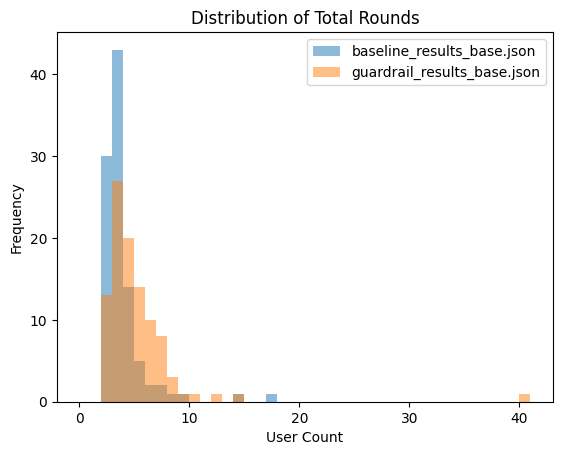

In [3]:
# plot distribution

import matplotlib.pyplot as plt
plt.hist(user_cnt_1, bins=range(0, max(user_cnt_1) + 2), alpha=0.5, label=file_1)
plt.hist(user_cnt_2, bins=range(0, max(user_cnt_2) + 2), alpha=0.5, label=file_2)
plt.xlabel("User Count")
plt.ylabel("Frequency")
plt.title("Distribution of Total Rounds")
plt.legend()
plt.show()